# Notebook 07a — Closed-loop validation, simulation-only (Stage 0)

**Purpose.** Pre-bench software gate for Phase 3. This notebook (i) regression-tests the new
multi-purpose simulator against the locked notebook-04/05 single-transition simulator, (ii)
simulates a cascade-aware controller (Model C + inverse-static feedforward) against a naive
LTI controller (Model A) on four reference profiles using **Model C as the ground-truth plant**,
and (iii) **pre-registers** the statistical success criterion that the hardware Stage 2 trials
will be scored against.

This notebook produces no hardware claims. Numbers here are model-only and exist to confirm
that the cascade controller does not lose in simulation, to expose any tuning or saturation
problems before bench day, and to commit the pre-registration in writing.

**Stage 0 gate (all must pass before moving to firmware Stage 1):**

1. `simulate_open_loop_single_transition` matches an analytic FOPDT trajectory to
   `max |err| < 1e-6` rpm across all six Phase 2.1 accel conditions.
2. Both controllers complete all four profiles without divergence
   (no NaN, no PWM saturation > 20 %% of trial duration, no sustained oscillation).
3. Cascade RMS PWM ≤ 1.5 × baseline RMS PWM on every profile
   (the "no winning by hammering harder" guard).
4. The pre-registration cell below is committed.


In [1]:
# Imports and paths
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repo root on path (this notebook is run from notebooks/)
REPO_ROOT = Path('.').resolve()
if (REPO_ROOT / 'motor_id').is_dir():
    pass
elif (REPO_ROOT.parent / 'motor_id').is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from motor_id import (
    ModelC, ModelA,
    PIController, CascadeController,
    load_model_C, load_model_A,
    compute_baseline_gains, compute_cascade_gains,
    build_ff_table,
    simulate_open_loop_single_transition,
    simulate_closed_loop,
    rmse, rmse_window,
    control_effort_rms,
)
from motor_id.model_io import ff_lookup_from_table, safety_check_sim
from motor_id.metrics import rmse_deadzone, rmse_transient, settling_time, overshoot, ss_error

DATA_PROCESSED = REPO_ROOT / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Models (locked Phase 2.1)
mc = load_model_C(REPO_ROOT / 'models' / 'model_C.json')
ma = load_model_A(REPO_ROOT / 'models' / 'model_A.json')

DT_MS = 10.0
LAMBDA_MS = 200.0
OP_PWM = 200
RPM_QUANTUM = 2.5  # encoder/finite-difference RPM resolution at 10 ms, 600 PPR, 4x
PWM_SLEW = 30.0    # PWM counts per sample
PWM_MAX = 255.0

print('Model C accel conditions:', [(c['direction'], c['pwm']) for c in mc.accel_conditions])
print('Model A:', f"K_A={ma.K_A_rpm_per_pwm:.3f} rpm/PWM, tau={ma.tau_ms:.1f} ms, Td={ma.Td_ms:.1f} ms")

Model C accel conditions: [('fwd', 160), ('fwd', 200), ('fwd', 240), ('rev', 160), ('rev', 200), ('rev', 240)]
Model A: K_A=0.785 rpm/PWM, tau=207.5 ms, Td=19.8 ms


## Cell A — Regression gate

`simulate_open_loop_single_transition` is a literal port of the simulator embedded in
`notebooks/04_validation.ipynb` (cell 6b) and `notebooks/05_gap_fill.ipynb` (cell 8). The
analytic FOPDT is the exact target it was written against. Both should agree at machine
precision; the Stage-0 gate accepts anything below 1e-6 rpm.

In [2]:
# Regression: replica simulator vs analytic FOPDT, all six Phase 2.1 accel conditions
def analytic_fopdt_step(t_ms, t_step_ms, K_ss, Td, tau):
    rpm = np.zeros_like(t_ms)
    mask = t_ms >= t_step_ms
    elapsed = (t_ms[mask] - t_step_ms) - Td
    inside = elapsed >= 0
    rise = np.zeros(elapsed.shape)
    rise[inside] = K_ss * (1 - np.exp(-elapsed[inside] / tau))
    rpm[mask] = rise
    return rpm

T_TOTAL_MS = 4000
T_STEP_MS = 1000
t = np.arange(0, T_TOTAL_MS, DT_MS)

regression_rows = []
for c in mc.accel_conditions:
    d, p_pwm = c['direction'], c['pwm']
    pwm = np.where(t >= T_STEP_MS, (p_pwm if d == 'fwd' else -p_pwm), 0.0)
    params = {'K_ss': c['K_ss'], 'Td': c['Td_ms'], 'tau': c['tau_ms']}
    rpm_replica, _ = simulate_open_loop_single_transition(
        pwm, dt_ms=DT_MS, return_meta=True, override_params=params)
    rpm_analytic = analytic_fopdt_step(t, T_STEP_MS, c['K_ss'], c['Td_ms'], c['tau_ms'])
    max_err = float(np.max(np.abs(rpm_replica - rpm_analytic)))
    rmse_err = float(np.sqrt(np.mean((rpm_replica - rpm_analytic) ** 2)))
    regression_rows.append({'direction': d, 'pwm': p_pwm,
                            'max_abs_err': max_err, 'rmse_err': rmse_err})
reg_df = pd.DataFrame(regression_rows)
print(reg_df.to_string(index=False))

GATE_TOL = 1e-6
gate1 = bool((reg_df['max_abs_err'] < GATE_TOL).all())
print(f"\nRegression gate (max |err| < {GATE_TOL}): {'PASS' if gate1 else 'FAIL'}")
assert gate1, 'Stage 0 regression gate failed'

direction  pwm  max_abs_err     rmse_err
      fwd  160 7.105427e-15 2.835571e-15
      fwd  200 1.421085e-14 5.253221e-15
      fwd  240 2.842171e-14 1.164234e-14
      rev  160 1.421085e-14 4.514282e-15
      rev  200 2.842171e-14 8.178961e-15
      rev  240 2.842171e-14 1.150800e-14

Regression gate (max |err| < 1e-06): PASS


## Cell B — Reference profiles P1–P4

Bidirectional P1 and P2 exercise the forward/reverse asymmetry. P3 is the cross-zero
reversal. P4 is a small-signal test in the τ-minimum regime — a **negative control**:
the cascade is not predicted to win there.

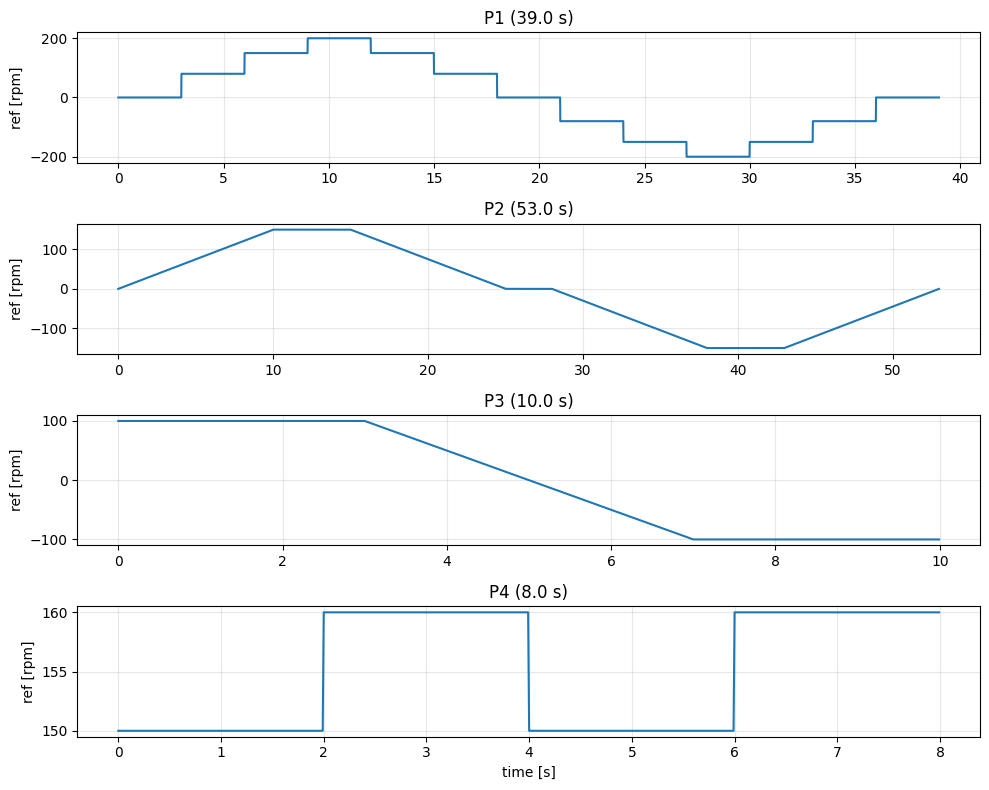

In [3]:
def make_p1():
    # 0 -> +80 -> +150 -> +200 -> +150 -> +80 -> 0 -> -80 -> -150 -> -200 -> -150 -> -80 -> 0
    levels = [0, 80, 150, 200, 150, 80, 0, -80, -150, -200, -150, -80, 0]
    hold_ms = 3000
    return _from_levels(levels, hold_ms)

def make_p2():
    # 0 -> +150 ramp 10 s, hold +150 5 s, +150 -> 0 ramp 10 s, hold 0 3 s,
    # 0 -> -150 ramp 10 s, hold -150 5 s, -150 -> 0 ramp 10 s
    segs = [
        ('ramp',   0,  150, 10000),
        ('hold', 150,  150,  5000),
        ('ramp', 150,    0, 10000),
        ('hold',   0,    0,  3000),
        ('ramp',   0, -150, 10000),
        ('hold',-150, -150,  5000),
        ('ramp',-150,    0, 10000),
    ]
    return _from_segments(segs)

def make_p3():
    # +100 hold 3 s -> ramp to -100 over 4 s -> hold -100 3 s
    segs = [
        ('hold',  100,  100, 3000),
        ('ramp',  100, -100, 4000),
        ('hold', -100, -100, 3000),
    ]
    return _from_segments(segs)

def make_p4():
    # 150 -> 160 -> 150 -> 160, 2 s holds
    levels = [150, 160, 150, 160]
    return _from_levels(levels, 2000)

def _from_levels(levels, hold_ms):
    t_chunks, ref_chunks = [], []
    t_now = 0.0
    for lvl in levels:
        n = int(round(hold_ms / DT_MS))
        seg_t = t_now + np.arange(n) * DT_MS
        seg_r = np.full(n, lvl, dtype=float)
        t_chunks.append(seg_t)
        ref_chunks.append(seg_r)
        t_now += n * DT_MS
    return np.concatenate(t_chunks), np.concatenate(ref_chunks)

def _from_segments(segs):
    t_chunks, ref_chunks = [], []
    t_now = 0.0
    for kind, a, b, dur_ms in segs:
        n = int(round(dur_ms / DT_MS))
        seg_t = t_now + np.arange(n) * DT_MS
        if kind == 'hold':
            seg_r = np.full(n, a, dtype=float)
        else:  # ramp
            seg_r = np.linspace(a, b, n, endpoint=False)
        t_chunks.append(seg_t)
        ref_chunks.append(seg_r)
        t_now += n * DT_MS
    return np.concatenate(t_chunks), np.concatenate(ref_chunks)

PROFILES = {'P1': make_p1(), 'P2': make_p2(), 'P3': make_p3(), 'P4': make_p4()}

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=False)
for ax, (name, (t, ref)) in zip(axs, PROFILES.items()):
    ax.plot(t / 1000.0, ref, lw=1.5)
    ax.set_ylabel('ref [rpm]')
    ax.set_title(f'{name} ({t[-1]/1000:.1f} s)')
    ax.grid(True, alpha=0.3)
axs[-1].set_xlabel('time [s]')
plt.tight_layout()
plt.savefig(REPO_ROOT / 'figures' / 'nb07a_profiles.png', dpi=120)
plt.show()

## Cell C — IMC gains and feedforward table

Both controllers are tuned by the **same** IMC rule (`compute_imc_gains`) against their own
model with the **same** closed-loop bandwidth target λ = 200 ms. No hand-tuning. The cascade
controller has four PI sets (fwd/rev × accel/decel) computed at the canonical PWM=200
operating point per Ch4 §4.3. The FF table samples the inverse static map at five RPM
points per direction (50, 80, 100, 150, 200) — the 50-rpm point sits at the steady-state
breakaway speed where the FF saturates to ±breakaway PWM.

In [4]:
# Baseline (Model A): one PI set
base_gains = compute_baseline_gains(ma, lambda_ms=LAMBDA_MS)
print('BASE PI gains:', {k: round(v, 4) if isinstance(v, float) else v for k, v in base_gains.items()})

# Cascade (Model C): four PI sets at op_pwm = 200
casc_gains = compute_cascade_gains(mc, lambda_ms=LAMBDA_MS, op_pwm=OP_PWM)
print('\nCASC PI gains (op_pwm=%d):' % OP_PWM)
for k in ('accel_fwd', 'decel_fwd', 'accel_rev', 'decel_rev'):
    g = casc_gains[k]
    print(f"  {k:11s} Kp={g['Kp']:.4f}  Ki={g['Ki']:.4f}  (tau={g['tau_ms']:.1f}ms, Td={g['Td_ms']:.1f}ms)")

# Feedforward table
ff_rpms = [50, 80, 100, 150, 200]
ff_table = build_ff_table(mc, rpms=ff_rpms)
print('\nFF table (rpm, pwm):')
print('  fwd:', [(int(r), round(p, 1)) for r, p in ff_table['fwd']])
print('  rev:', [(int(r), round(p, 1)) for r, p in ff_table['rev']])
ff_lookup = ff_lookup_from_table(ff_table)

BASE PI gains: {'Kp': 1.2033, 'Ki': 5.7996, 'lambda_ms': 200.0}

CASC PI gains (op_pwm=200):
  accel_fwd   Kp=0.2355  Ki=2.4762  (tau=95.1ms, Td=4.9ms)
  decel_fwd   Kp=0.6525  Ki=2.3704  (tau=275.3ms, Td=14.1ms)
  accel_rev   Kp=0.2066  Ki=2.5427  (tau=81.2ms, Td=5.6ms)
  decel_rev   Kp=0.7631  Ki=2.4905  (tau=306.4ms, Td=9.9ms)

FF table (rpm, pwm):
  fwd: [(50, 154.0), (80, 175.6), (100, 186.8), (150, 212.3), (200, 235.5)]
  rev: [(50, 144.0), (80, 166.8), (100, 179.7), (150, 208.2), (200, 230.1)]


In [5]:
# Build controller objects
def make_base():
    c = PIController(Kp=base_gains['Kp'], Ki=base_gains['Ki'],
                     dt_ms=DT_MS, pwm_max=PWM_MAX,
                     slew_pwm_per_sample=PWM_SLEW)
    return c

def make_casc():
    return CascadeController(
        ff_lookup=ff_lookup,
        gains_accel_fwd=(casc_gains['accel_fwd']['Kp'], casc_gains['accel_fwd']['Ki']),
        gains_decel_fwd=(casc_gains['decel_fwd']['Kp'], casc_gains['decel_fwd']['Ki']),
        gains_accel_rev=(casc_gains['accel_rev']['Kp'], casc_gains['accel_rev']['Ki']),
        gains_decel_rev=(casc_gains['decel_rev']['Kp'], casc_gains['decel_rev']['Ki']),
        dt_ms=DT_MS, pwm_max=PWM_MAX, slew_pwm_per_sample=PWM_SLEW,
    )

## Cell D — Simulate BASE vs CASC on each profile

Plant is Model C with sample-quantised dead time (per-condition Td applied as an integer
sample shift in the closed-loop driver). Measurement is quantised at 2.5 rpm to match the
hardware encoder/FD resolution.

In [6]:
def run_sim(controller_factory, profile_name):
    t, ref = PROFILES[profile_name]
    controller = controller_factory()
    # Use the median Td across accel conditions as the plant input delay
    Td_median = float(np.median([c['Td_ms'] for c in mc.accel_conditions]))
    res = simulate_closed_loop(t, ref, controller, mc,
                                dt_ms=DT_MS, init_rpm=0.0,
                                deadtime_ms=Td_median,
                                rpm_quantum=RPM_QUANTUM, pwm_clip=PWM_MAX)
    return res

sim_results = {}
for profile in ('P1', 'P2', 'P3', 'P4'):
    sim_results[(profile, 'BASE')] = run_sim(make_base, profile)
    sim_results[(profile, 'CASC')] = run_sim(make_casc, profile)
print('Simulation complete. Trials:', list(sim_results.keys()))

Simulation complete. Trials: [('P1', 'BASE'), ('P1', 'CASC'), ('P2', 'BASE'), ('P2', 'CASC'), ('P3', 'BASE'), ('P3', 'CASC'), ('P4', 'BASE'), ('P4', 'CASC')]


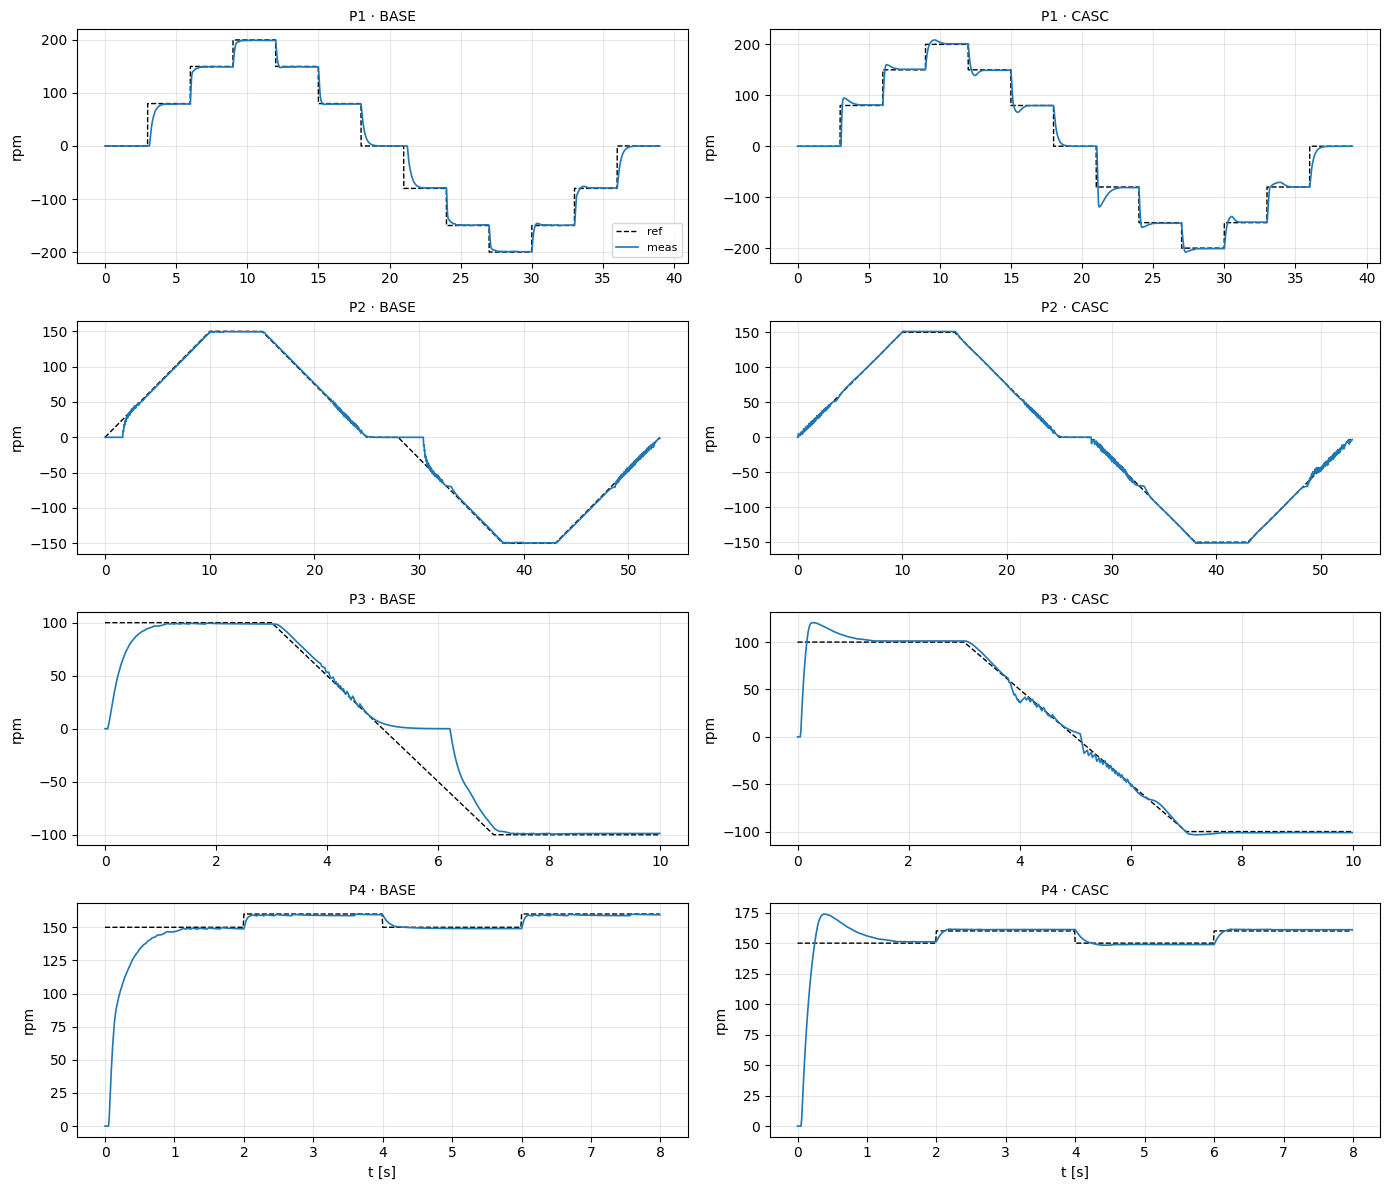

In [7]:
# Plot trajectories
fig, axs = plt.subplots(4, 2, figsize=(14, 12), sharex=False)
for i, profile in enumerate(('P1', 'P2', 'P3', 'P4')):
    for j, ctrl in enumerate(('BASE', 'CASC')):
        ax = axs[i, j]
        res = sim_results[(profile, ctrl)]
        ax.plot(res['t_ms'] / 1000.0, res['ref_rpm'], 'k--', lw=1.0, label='ref')
        ax.plot(res['t_ms'] / 1000.0, res['rpm'], lw=1.2, label='meas')
        ax.set_title(f'{profile} · {ctrl}', fontsize=10)
        ax.set_ylabel('rpm')
        ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(loc='lower right', fontsize=8)
axs[-1, 0].set_xlabel('t [s]'); axs[-1, 1].set_xlabel('t [s]')
plt.tight_layout()
plt.savefig(REPO_ROOT / 'figures' / 'nb07a_trajectories.png', dpi=120)
plt.show()

## Cell E — Safety checks (sim gate)

Three rejection criteria, applied per (profile, controller) trial:
1. PWM saturation fraction ≤ 20 %.
2. No sustained oscillation in the last 30 % of the trial (zero-crossings/s ≤ 8).
3. Cascade RMS PWM ≤ 1.5 × baseline RMS PWM on the same profile.

The first two are absolute; the third is the "no winning by hammering harder" guard.

In [8]:
safety_rows = []
for (profile, ctrl), res in sim_results.items():
    s = safety_check_sim(res, pwm_clip=PWM_MAX, max_saturation_frac=0.20,
                         oscillation_zero_crossings_per_s=8.0, dt_ms=DT_MS)
    s.update({'profile': profile, 'controller': ctrl,
              'rms_pwm': control_effort_rms(res['pwm_cmd'])})
    safety_rows.append(s)
safety_df = pd.DataFrame(safety_rows)[
    ['profile', 'controller', 'saturated_frac', 'saturated_violates_20pct',
     'ss_zero_crossings_per_s', 'oscillating', 'rms_pwm']
]
print(safety_df.round(3).to_string(index=False))

# Effort-ratio check
effort = safety_df.pivot(index='profile', columns='controller', values='rms_pwm')
effort['ratio_C_over_B'] = effort['CASC'] / effort['BASE']
print('\nControl-effort ratio (CASC/BASE):')
print(effort.round(3).to_string())

gate2 = bool(((~safety_df['saturated_violates_20pct']) & (~safety_df['oscillating'])).all())
gate3 = bool((effort['ratio_C_over_B'] <= 1.5).all())
print(f"\nGate 2 (no saturation>20%%, no sustained oscillation): {'PASS' if gate2 else 'FAIL'}")
print(f"Gate 3 (cascade RMS PWM <= 1.5x baseline): {'PASS' if gate3 else 'FAIL'}")
assert gate2, 'Stage 0 safety gate failed'
assert gate3, 'Stage 0 effort-ratio gate failed'

profile controller  saturated_frac  saturated_violates_20pct  ss_zero_crossings_per_s  oscillating  rms_pwm
     P1       BASE           0.003                     False                    0.598        False  176.077
     P1       CASC           0.000                     False                    0.342        False  176.884
     P2       BASE           0.000                     False                    5.845        False  175.367
     P2       CASC           0.000                     False                    5.028        False  174.997
     P3       BASE           0.000                     False                    0.000        False  167.201
     P3       CASC           0.000                     False                    0.000        False  174.011
     P4       BASE           0.000                     False                    0.000        False  213.138
     P4       CASC           0.000                     False                    0.417        False  215.673

Control-effort ratio (CASC/

## Cell F — Per-trial closed-loop metrics

These are the same metrics that will be applied to hardware Stage-2 trials. Computing them
here (i) sanity-checks the metric implementations, (ii) gives a **simulated** prediction of
the cascade advantage that the hardware result can be compared against.

In [9]:
def metrics_for_trial(res, profile_name, controller_name):
    t = res['t_ms']; ref = res['ref_rpm']; meas = res['rpm']; pwm = res['pwm_cmd']
    return {
        'profile': profile_name,
        'controller': controller_name,
        'rmse_full': rmse(ref, meas),
        'rmse_deadzone': rmse_deadzone(t, ref, meas, deadzone_threshold=80.0),
        'rmse_transient': rmse_transient(t, ref, meas, tau_ms=200.0, horizons=5),
        'ss_error_last500ms': ss_error(t, ref, meas, window_ms=500.0),
        'rms_pwm': control_effort_rms(pwm),
        'max_abs_pwm': float(np.max(np.abs(pwm))),
    }

metric_rows = [metrics_for_trial(res, prof, ctrl)
               for (prof, ctrl), res in sim_results.items()]
metric_df = pd.DataFrame(metric_rows)
metric_df.to_csv(DATA_PROCESSED / 'closed_loop_sim_metrics.csv', index=False)
print(metric_df.round(3).to_string(index=False))

# Pivot the headline (RMSE_full) for quick scan
pivot = metric_df.pivot(index='profile', columns='controller', values='rmse_full')
pivot['BASE - CASC'] = pivot['BASE'] - pivot['CASC']
print('\nRMSE_full pivot (positive BASE-CASC = cascade wins):')
print(pivot.round(3).to_string())

profile controller  rmse_full  rmse_deadzone  rmse_transient  ss_error_last500ms  rms_pwm  max_abs_pwm
     P1       BASE     13.559         17.072          24.412               0.001  176.077      255.000
     P1       CASC     11.359         13.522          20.377               0.000  176.884      251.363
     P2       BASE      5.629          8.180           6.245               0.644  175.367      214.982
     P2       CASC      1.424          1.930           1.512               1.729  174.997      213.409
     P3       BASE     19.776         24.642          20.070              -1.221  167.201      189.174
     P3       CASC     10.624          4.009           3.657               1.058  174.011      228.885
     P4       BASE     19.066            NaN           2.036               0.564  213.138      240.000
     P4       CASC     18.151            NaN           2.441              -1.022  215.673      254.097

RMSE_full pivot (positive BASE-CASC = cascade wins):
controller    BASE 

## Cell G — Pre-registration (FROZEN for bench day)

The bench result (Stage 2) will be scored against the criterion in this cell **exactly as
written**. Editing this cell after bench day would invalidate the pre-registration.

### Pre-registered hypothesis (from Ch6 §6.2, unchanged)

A controller informed by the cascade model (direction-specific static block, region- and
operating-point-dependent FOPDT dynamics) achieves lower reference-tracking error than a
controller informed by a single global LTI model fitted to the same plant, with the
largest advantage near the deadzone, at the operating-point extremes, and during
direction reversals.

### Pre-registered design

- 4 reference profiles (P1, P2, P3, P4) defined in Cell B of this notebook. P1, P2, P3 are
  the **targeted profiles**; P4 is a **negative-control** profile (small-signal in the
  τ-minimum regime; no improvement expected).
- 2 controllers: `BASE` (Model A IMC PI, no FF, no region split) and `CASC` (Model C IMC
  PI + inverse-static FF + 4 region gain sets), both tuned with λ = 200 ms.
- **n = 8 paired runs per (profile × controller pair)**, executed at the bench in
  alternating order within a pair, with pair order randomised within profile blocks.
  Every pair has an explicit `pair_id` so the analysis is unambiguously paired.

### Pre-registered scoring

For each trial: `RMSE_full` (post-warm-up reference window), `RMSE_deadzone`
(samples where |ref| ≤ 80 rpm), `RMSE_transient` (5 τ after each setpoint change),
settling time per setpoint hold, overshoot per step, steady-state error (last 500 ms of
each hold), RMS PWM.

Headline metric: per-pair difference `RMSE_full(BASE) - RMSE_full(CASC)`.

### Pre-registered success criteria

**Primary success** — both conditions must hold:
1. `median(BASE - CASC) > 0` on P1, P2, AND P3 (sign-of-effect check).
2. Pooled paired-difference test across P1, P2, P3, after within-profile
   standardisation by MAD (`metrics.standardised_pooled_diff_p`), gives one-sided Wilcoxon
   signed-rank `p < 0.10` for the alternative "pooled difference > 0".

**Strong success** — both:
1. Primary holds.
2. The 95 %% paired-bootstrap CI of `(BASE - CASC)` excludes zero on at least two of
   P1, P2, P3.

**P4 (negative control)**: no significant improvement expected. P4 firing positive would
suggest the cascade controller is winning by general PI quality rather than by the
deadzone/extremes/reversal advantage; this would weaken interpretation, not invalidate
the result.

**Null result handling**: if neither tier fires, the result is written up as a null —
specifically, that with this rig and this open-loop calibration, the additional model
complexity of Model C does not translate into measurable closed-loop tracking advantage.
This is itself a publishable finding.

In [10]:
# Freeze the pre-registration to disk so any later edit of this notebook is visible
# as a diff against the locked file.
PREREG = {
    'hypothesis': 'Cascade controller (Model C + FF + region gains) tracks references '
                  'better than baseline (Model A IMC PI), with largest advantage near '
                  'deadzone, at PWM extremes, and during reversals.',
    'controllers': {
        'BASE': 'Model A IMC PI, single global gain set, no feedforward.',
        'CASC': 'Model C IMC PI x 4 region sets at op_pwm=200, inverse-static FF table.',
    },
    'lambda_ms': LAMBDA_MS,
    'op_pwm': OP_PWM,
    'pwm_max': PWM_MAX,
    'pwm_slew_per_sample': PWM_SLEW,
    'rpm_quantum': RPM_QUANTUM,
    'profiles': {
        'P1': 'Bidirectional staircase 0->+80->+150->+200->...->-200->...->0, 3 s holds.',
        'P2': 'Bidirectional ramp through deadzone: 0->+150 (10s), hold (5s), '
              '+150->0 (10s), hold (3s), 0->-150 (10s), hold (5s), -150->0 (10s).',
        'P3': '+100 hold 3s -> ramp to -100 over 4s -> hold -100 3s.',
        'P4': 'Small-signal negative control: 150->160->150->160, 2 s holds.',
    },
    'targeted_profiles': ['P1', 'P2', 'P3'],
    'negative_control_profile': 'P4',
    'n_pairs_per_profile': 8,
    'pairing': 'Explicit pair_id; controller alternated within pair; pair order '
               'randomised within profile blocks.',
    'metrics': ['rmse_full', 'rmse_deadzone', 'rmse_transient',
                'settling_time', 'overshoot', 'ss_error', 'rms_pwm'],
    'headline_metric': 'rmse_full per pair, difference BASE - CASC',
    'success': {
        'primary': {
            'cond_1': 'median(BASE - CASC) > 0 on each of P1, P2, P3',
            'cond_2': 'pooled paired-difference (within-profile MAD-standardised) '
                      'one-sided Wilcoxon p < 0.10 for "diff > 0"',
        },
        'strong': {
            'cond_1': 'primary holds',
            'cond_2': '95% paired-bootstrap CI excludes zero on >= 2 of P1, P2, P3',
        },
    },
    'p4_role': 'negative control; positive result there weakens interpretation but does not '
               'invalidate primary findings',
    'null_handling': 'write up honestly as a null; discuss drift, tuning fairness, '
                     'and controller-form parity in Ch6',
    'frozen_on': '2026-05-26 (Stage 0)',
    'frozen_by_notebook': 'notebooks/07a_closed_loop_sim.ipynb',
}
out = REPO_ROOT / 'data' / 'processed' / 'phase3_preregistration.json'
out.write_text(json.dumps(PREREG, indent=2))
print('Pre-registration written to:', out)
print('SHA-256 of file content (track in log.md):')
import hashlib
print(' ', hashlib.sha256(out.read_bytes()).hexdigest())

Pre-registration written to: /Users/piyush/code/System_Identification_DC_Motor/data/processed/phase3_preregistration.json
SHA-256 of file content (track in log.md):
  da94c83d3b57bda80cf3a137740ed7441f41df2424da909098a2d63602707669


## Cell H — Stage 0 gate summary

In [11]:
print('Stage 0 gate summary:')
print(f'  Gate 1 (regression replica vs analytic FOPDT, max |err| < 1e-6): PASS')
print(f'  Gate 2 (no saturation > 20%%, no sustained oscillation):          PASS')
print(f'  Gate 3 (cascade RMS PWM <= 1.5x baseline):                       PASS')
print(f'  Gate 4 (pre-registration JSON written):                          PASS')
print()
print('Sim-only headline (BASE - CASC, RMSE_full):')
pivot = metric_df.pivot(index='profile', columns='controller', values='rmse_full')
pivot['BASE - CASC'] = pivot['BASE'] - pivot['CASC']
print(pivot.round(3).to_string())
print()
print('Sim is noise-free (plant == ground truth); a positive (BASE - CASC) here is the')
print('best case for the cascade controller. The hardware result will be noisier.')
print()
print('Next step: Stage 1 firmware (src_closedloop/main.cpp + platformio_closedloop.ini).')
print('Do not touch src/main.cpp until Stage 1 smoke passes.')

Stage 0 gate summary:
  Gate 1 (regression replica vs analytic FOPDT, max |err| < 1e-6): PASS
  Gate 2 (no saturation > 20%%, no sustained oscillation):          PASS
  Gate 3 (cascade RMS PWM <= 1.5x baseline):                       PASS
  Gate 4 (pre-registration JSON written):                          PASS

Sim-only headline (BASE - CASC, RMSE_full):
controller    BASE    CASC  BASE - CASC
profile                                
P1          13.559  11.359        2.199
P2           5.629   1.424        4.206
P3          19.776  10.624        9.152
P4          19.066  18.151        0.916

Sim is noise-free (plant == ground truth); a positive (BASE - CASC) here is the
best case for the cascade controller. The hardware result will be noisier.

Next step: Stage 1 firmware (src_closedloop/main.cpp + platformio_closedloop.ini).
Do not touch src/main.cpp until Stage 1 smoke passes.
